# HW 15 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 9th, 2025 at 11:59pm** on Gradescope

## 1 Modify the Animation from Lecture
Modify the given sine wave animation so that the wave moves twice as fast. What parts of the code you you need to change, and why? Please specifically highlight this in your code

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation

In [27]:
#Making it so the frames are less smooth (meaning bigger jumps between frames) and then decreasing the intervals between frames (increasing fps, essentially) makes the animation faster. I initially thought making the interval=1 would make it fastest, but I don't think my computer could process that animation so I cut the original number (50) in half instead.

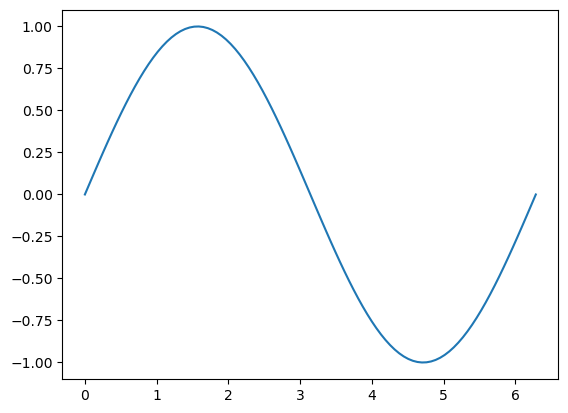

In [18]:
x = np.linspace(0, 2 * np.pi, 100)
fig, ax = plt.subplots()
line, = ax.plot(x, np.sin(x))

def update(frame):
    """
    Updating my sine function by shifting horizontally 
    frame (integer) = current frame number, increasing with
    line, (tuple) = the updated line object (being redrawn)
    """
    line.set_ydata(np.sin(x + frame/5.0))

    return line,

amm = animation.FuncAnimation(fig, update, frames = 100, interval = 25, blit = True)

plt.show()

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [70]:
amm.save("sinefaster2.gif", writer = "pillow", fps = 20) #sinefaster2 is the final answer

Explain what happens if you set `blit=True` in `FuncAnimation`? What happens if you set it to `blit=False`?

In [29]:
#blit = True makes it so computer only updates differences between each frame, making for rendering time to be faster. If blit = False, the entire image is redrawn on top of the previous frame.

## 2 A Different Animation
Write an animation where a dot moves in a circular path instead of sine wave. *Hint: You will need to use `np.sin` and `np.cos`. 

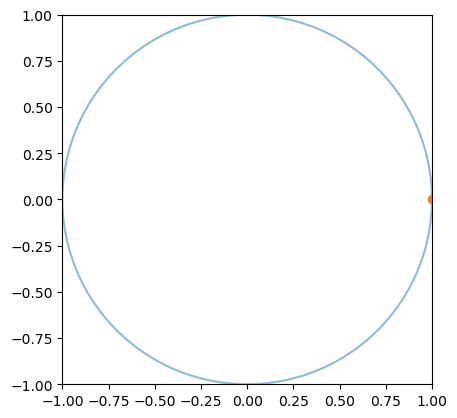

In [65]:
points = np.linspace(0, 2 * np.pi, 100)
x = np.cos(points)
y = np.sin(points)

#perfect circle instead of stretched one
fig, ax = plt.subplots()
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect("equal")

#create the circle traced path
ax.plot(x, y, alpha = 0.5)

#initialize the point (x and y values to be added later)
point, = ax.plot([], [], 'o') 

def update(frame):
    x = (np.cos(frame/10.0))
    y = (np.sin(frame/10.0))

    point.set_data([x], [y])

    return point,

ani = animation.FuncAnimation(fig, update, frames = 100, interval = 50, blit = True)

plt.show()

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [63]:
ani.save("circle.gif", writer = "pillow", fps = 20)

## 3 Simulate Orbital Motion of Planets and a Comet
**Check out the `example_solar_system_animation.mp4` as an example of what you will be creating in this problem.**

Now you will simulate and visualize the orbital motion of Earth, Mars and a coment around the Sun using Newtonian gravity and Python. Here are the steps:
* Calculate the gravitational forces acting on each body.
* Update positions and velocities over time.
* Simulate the motion of these celestial bodies over a period of 5 years.
* Animate the results to observe orbital patterns. 

Let's dig a bit into the physics. The motion of celestial bodies follows **Newton's laws of motion and gravitation**:
$$
F = G \frac{m_1 m_1}{r^2}
$$

where:
* $F$ is the gravitational force.
* $G = 6.67\times10^{-11}$ is the gravitational constant
* $m_1$, $m_2$ are the measses of the two objects.
* $r$ is the distance between them.

Using **Newton's Second Law**, the acceleration is given by:

$$
a = \frac{F}{m}
$$

where $a$ is the acceleration, and $m$ is the object's mass. The velocity and position are updated with numerical integration:

$$
v = v + a \cdot dt
$$

$$
x = x + v \cdot dt
$$

## 3.1 Implementing the Simulation
Goal: Set up the **masses**, **initial positions** and **velocities** for the Sun, Earth, Mars and a comet. 
* Use SI units (meters, kilograms, seconds).
* The Sun is at the origin (0, 0, 0)
* Earth, Mars and the commet start at **aphelion** (farthest from the Sun).

Start by defining the following initial variables in kilograms (or SI units):
* `G`
* `Ms` (the mass of the Sun, you will need to google this)
* `Me` (the mass of the Earth)
* `Mm` (the mass of Mars)
* `Mc = 6.39e20` (the mass of a comet)
* `AU` (astronomical unit, distance between Earth and the Sun)
* `daysec` (how many seconds are in a day)

In [437]:
G = 6.6743 * (10 ** -11)

Ms = 1.9891 * (10 ** 30)
Me = 5.97219 * (10 ** 24)
Mm = 6.39 * (10 ** 23)
Mc = 6.39e20

AU = 1.496e11

daysec = 86400

Now we will define some initial velocities in meters per second:
* `e_ap_v` (Earth at aphelion, google it, make sure its in SI units)
* `m_ap_v` (Mars at aphelion)
* `commet_v = 7000` (speed of the comet)

In [440]:

e_ap_v = 29290 #m/s

m_ap_v = 24000 #m/s

comet_v = 7000 #m/s

Run the cell below to define some gravitational constants because we expect no mass loss:

In [443]:
gravconst_e = G * (Me*Ms)

gravconst_m = G * (Mm*Ms)

gravconst_c = G * (Mc*Ms) 

Define the initial positions of the Earth, Mars and the comet. Here is the Earth as an example:
* `xe, ye, ze = 1.0167 * AU, 0, 0`

Follow the same pattern for Mars (where the `x` coordinate is at `1.666 * AU`, everything else is zero) and the comet (where the `x` coordinate is at `2* AU`, the `y` coordinate is `0.3 * AU` and the `z` coordinate is zero) . Remember the sun is at the origin! 

In [446]:
xe, ye, ze = 1.0167 * AU, 0, 0

xm, ym, zm = 1.666 * AU, 0, 0

xc, yc, zc = 2 * AU, 0.3 * AU, 0

We will do the same thing but for initial velocities. Here is Earth as an example:
* `xve, yve, zve = 0, e_ap_v, 0`

Make variables for Mars but with `m_ap_v` as the `y` coordinate. Make variables for the commet but with `commet_v` as the `y` coordinate.

In [449]:
xve, yve, zve = 0, e_ap_v, 0

xvm, yvm, zvm = 0, m_ap_v, 0

xvc, yvc, zvc = 0, comet_v, 0

Assume the Sun is at the origin. Make initial positions and velocities for the Sun. It should not be moving so all its velocities coordinates are zero. 

In [452]:
xs, ys, zs = 0, 0, 0

xvs, yvs, zvs = 0, 0, 0

Now we will define some time parameters for our simulation. Create variable for the initial time `t` and set it to zero. Create a variable called `dt` for the change in time (steps per day) and set it to `1 * daysec`. Create a varible for `years` and set it to `5`. Finally, create a varible for `sim_years` and set it equal to `years * 365 * daysec`.

In [455]:
t = 0
dt = 1 * daysec
years = 5
sim_years = years * 365 * daysec

dt

86400

Create empty lists to store all of your variables. Run the cell below.

In [458]:
xelist, yelist = [], []

xmlist, ymlist = [], []

xclist, yclist = [], []

xslist, yslist = [], []

earth_vs = []
mars_vs = []
comet_vs = []
sun_vs = []


## 3.2 Compute Gravitational Forces and Update Positions
Goal:
* Implement the **gravitational force equation** to calculate the force acting on each body.
* Compute accelerations using $a = F/m$.
* Update **velocity** and **position**.
* Use a loop to update positions over **5 years**.
* Store the results in lists for plotting.

I will do this part for you, it requires some physics knowledge. But you need to turn this into a loop for when time is less than the simulation time. You want the loop to repeat it itself until that condition is met. 

In [315]:
while t < sim_years:

################ Earth #############
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -gravconst_e * rx / modr3_e
    fy_e = -gravconst_e * ry / modr3_e
    
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
    
    xelist.append(xe)
    yelist.append(ye)

################ Mars ##############
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -gravconst_m * rx_m / modr3_m
    fy_m = -gravconst_m * ry_m / modr3_m
    
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
    
    xmlist.append(xm)
    ymlist.append(ym)

################ Comet ##############
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -gravconst_c * rx_c / modr3_c
    fy_c = -gravconst_c * ry_c / modr3_c
    
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
        
    xclist.append(xc)
    yclist.append(yc)

################ Sun ##############
    xvs += -(fx_e + fx_m) * dt / Ms
    yvs += -(fy_e + fy_m) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    xslist.append(xs)
    yslist.append(ys)

    print(f"Earth Position: {xe}, {ye}")
    print(f"Mars Position: {xm}, {ym}")
    print(f"Comet Position: {xc}, {yc}")
    print(f"Sun Position: {xs}, {ys}")

    t += dt


xelist

Earth Position: 152055480835.52786, 2530656000.0
Mars Position: 249217645740.75247, 2073600000.0
Comet Position: 299189292904.59125, 45483193935.68868
Sun Position: 133.74812796137007, 0.0
Earth Position: 151969796167.4429, 5060598923.231636
Mars Position: 249185736836.3067, 4147067250.3618174
Comet Position: 299167887530.59283, 46084761503.41692
Sun Position: 401.2635408773638, 2.1836292615024258
Earth Position: 151841271121.9611, 7589115260.564814
Mars Position: 249137874171.61572, 6220268990.676613
Comet Position: 299135792046.35016, 46684682332.96829
Sun Position: 802.5305632057866, 8.735818654201708
Earth Position: 151669922310.34393, 10115491241.089628
Mars Position: 249074059902.7708, 8293072464.492665
Comet Position: 299093013974.149, 47282935982.46352
Sun Position: 1337.4986276790135, 21.842283759548895
Earth Position: 151455777846.52313, 12639013003.445728
Mars Position: 248994297457.02332, 10365344934.047804
Comet Position: 299039560192.41473, 47879501933.253456
Sun Position

[152055480835.52786,
 151969796167.4429,
 151841271121.9611,
 151669922310.34393,
 151455777846.52313,
 151198877362.63635,
 150899272022.44855,
 150557024532.63232,
 150172209151.8803,
 149744911697.82202,
 149275229551.7167,
 148763271660.89334,
 148209158538.908,
 147613022263.38855,
 146975006471.53622,
 146295266353.25226,
 145573968641.85828,
 144811291602.37814,
 144007425017.3486,
 143162570170.12543,
 142276939825.65204,
 141350758208.65634,
 140384260979.2422,
 139377695205.84064,
 138331319335.4867,
 137245403161.38666,
 136120227787.74127,
 134956085591.78941,
 133753280183.03749,
 132512126359.63925,
 131232950061.89108,
 129916088322.80768,
 128561889215.74338,
 127170711799.0244,
 125742926057.55757,
 124278912841.38148,
 122779063801.12617,
 121243781320.3481,
 119673478444.70734,
 118068578807.95474,
 116429516554.6972,
 114756736259.90977,
 113050692845.16437,
 111311851491.54512,
 109540687549.22183,
 107737686443.65323,
 105903343578.39337,
 104038164234.47504,
 102

## 3.3 Visualization
Goal: Plot the Orbits
* After simulating the motion, **plot the orbits of Earth, Mars and the comet**.
* Label the **Sun**, **Earth**, **Mars**, and **Comet**.

Start by making a figure, set the argument of`figsize=(8, 8)`.
* Plot the `yelist` as a function of `xelist`. Do this for the `xm`, `xc` and `xs` lists as well. Make sure each line is a **different color**!
  * The Sun will just be a point, so give it a markersize of `10`. Make it yellow.  
* Give it a legend
* Add an `xlabel` of `"X Position (m)"`.
* Add an `ylabel` of `"Y Position (m)"`.
* Give it a title.
* Add a grid.
* Show the plot.

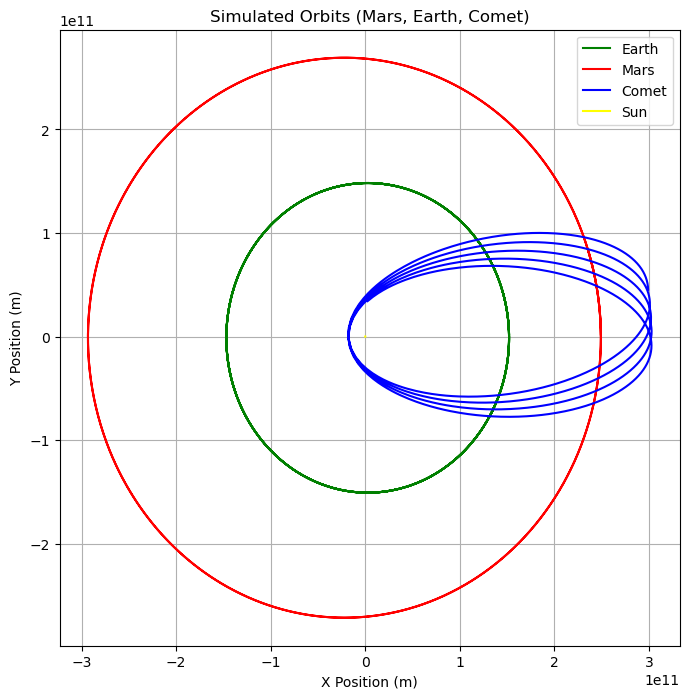

In [317]:
fig, ax = plt.subplots(figsize = (8,8))

ax.plot(xelist, yelist, color= "green", label = "Earth")
ax.plot(xmlist, ymlist, color = "red", label = "Mars")
ax.plot(xclist, yclist, color = "blue", label = "Comet")
ax.plot(xslist, yslist, color = "yellow", markersize = 10, label = "Sun")
ax.legend()
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title("Simulated Orbits (Mars, Earth, Comet)")
ax.grid()

plt.show()

Goal: Animate the Motion
* Create an animated visualization of planetary orbits.
* Track the motion of each body over time.

\
Follow the procedure from lecture. Here are some hints:
* Set the `x` and `y` limits to `-3 * AU` to `3 * AU`. \


* Unpack the lines for Earth, Mars, the commet. Example: 
  * `line_e = axplot([], [], '-g', lw=1)` \

  
* Unpack the points for Earth, Mars, the commet and the Sun. Example:
  * `point_e, = ax.plot([],[],'bo',markersize=4)` \

* Give a title to each of the objects. Example:
  * `text_e  = ax.text(AU,0,'Earth')`

* Create the `update` function and update the lines, points and text you just unpacked. Example:
  * `line_e.set_data(xelist[:i], yelist[:i])` 
  * `point_e.set_data(xelist[i], yelist[i])`\
  * `text_e.set_position((xelist[i],yelist[i]))`


* Create the animation! Set `frames = len(xelist)`, `interval=1` and `blit=True`. 

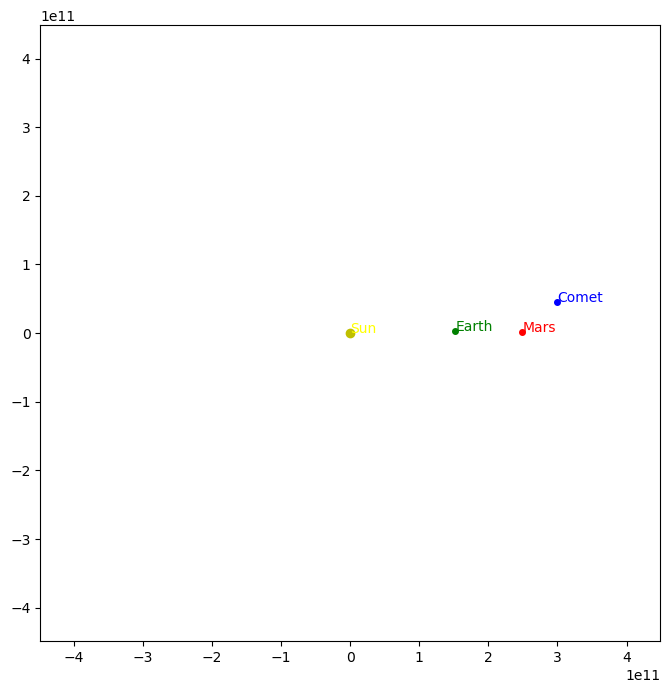

In [319]:
fig, ax = plt.subplots(figsize = (8,8))
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)

line_e, = ax.plot([], [], "-g", lw=1)
line_m, = ax.plot([], [], "-r", lw=1)
line_c, = ax.plot([], [], "-b", lw=1)

point_e, = ax.plot([], [], 'go', markersize=4)
point_m, = ax.plot([], [], 'ro', markersize=4)
point_c, = ax.plot([], [], 'bo', markersize=4)
point_s, = ax.plot([], [], 'yo', markersize=6)

text_e = ax.text(AU, 0, "Earth", color = "green")
text_m = ax.text(AU, 0, "Mars", color = "red")
text_c = ax.text(2*AU, 0, "Comet", color = "blue")
text_s = ax.text(0, 0, "Sun", color = "yellow")

def update(i):
    line_e.set_data(xelist[:i], yelist[:i])
    line_m.set_data(xmlist[:i], ymlist[:i])
    line_c.set_data(xclist[:i], yclist[:i])

    point_e.set_data([xelist[i]], [yelist[i]])
    point_m.set_data([xmlist[i]], [ymlist[i]])
    point_c.set_data([xclist[i]], [yclist[i]])
    point_s.set_data([xslist[i]], [yslist[i]])


    text_e.set_position((xelist[i], yelist[i]))
    text_m.set_position((xmlist[i], ymlist[i]))
    text_c.set_position((xclist[i], yclist[i]))
    text_s.set_position((xslist[i], yslist[i]))

    return line_e, line_m, line_c, point_e, point_m, point_c, point_s, text_e, text_m, text_c, text_s

aniorbit = animation.FuncAnimation(fig, update, frames = len(xelist), interval = 1, blit = True)


In [321]:
aniorbit.save("orbit.gif", writer = "pillow", fps = 20)

## 3.4 Add Mercury, Venus and the Moon!
As an extra challenge, give your best attempt at simulating Mercury, Venus and/or the Moon! I am not going to give you a ton of hints for this problem. Come to office hours if you have questions :)

In [526]:
Mv = 4.867 * (10 ** 24) #kg
v_ap_v = 34500 #m/s
grav_constv = G * (Mv * Ms)

xv, yv, zv = 0.73 * AU, 0, 0
xvv, yvv, zvv = 0, v_ap_v, 0

xvlist, yvlist = [], []

t = 0

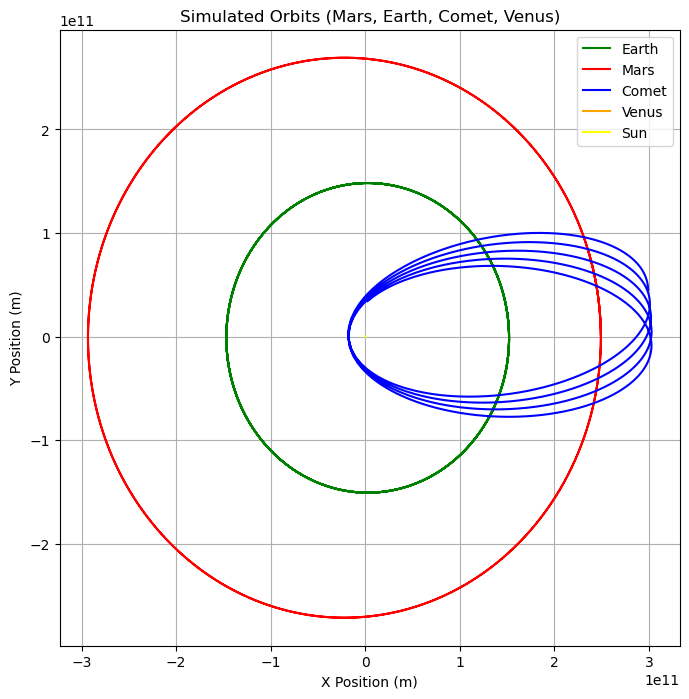

In [528]:
fig, ax = plt.subplots(figsize = (8,8))

ax.plot(xelist, yelist, color= "green", label = "Earth")
ax.plot(xmlist, ymlist, color = "red", label = "Mars")
ax.plot(xclist, yclist, color = "blue", label = "Comet")
ax.plot(xvlist, yvlist, color = "orange", label = "Venus")
ax.plot(xslist, yslist, color = "yellow", markersize = 10, label = "Sun")
ax.legend()
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title("Simulated Orbits (Mars, Earth, Comet, Venus)")
ax.grid()

plt.show()

In [534]:
while t < sim_years:

################ Earth #############
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -gravconst_e * rx / modr3_e
    fy_e = -gravconst_e * ry / modr3_e
    
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
    
    xelist.append(xe)
    yelist.append(ye)

################ Mars ##############
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -gravconst_m * rx_m / modr3_m
    fy_m = -gravconst_m * ry_m / modr3_m
    
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
    
    xmlist.append(xm)
    ymlist.append(ym)

################ Comet ##############
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -gravconst_c * rx_c / modr3_c
    fy_c = -gravconst_c * ry_c / modr3_c
    
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
        
    xclist.append(xc)
    yclist.append(yc)

############# Venus ###############
    rx_v, ry_v, rz_v = xv - xs, yv - ys, zv - zs
    modr3_v = (rx_v ** 2 + ry_v ** 2 + rz_v ** 2) ** 1.5
    fx_v = -grav_constv * rx_v / modr3_v
    fy_v = -grav_constv * ry_v / modr3_v

    xvv += fx_v * dt / Mv
    yvv += fy_v * dt / Mv
    xv += xvv * dt
    yv += yvv * dt
    
    xvlist.append(xv)
    yvlist.append(yv)


################ Sun ##############
    xvs += -(fx_e + fx_m) * dt / Ms
    yvs += -(fy_e + fy_m) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    xslist.append(xs)
    yslist.append(ys)

    print(f"Earth Position: {xe}, {ye}")
    print(f"Mars Position: {xm}, {ym}")
    print(f"Comet Position: {xc}, {yc}")
    print(f"Venus Position: {xv}, {yv}")
    print(f"Sun Position: {xs}, {ys}")
    
    t += dt

Earth Position: 151872234305.35876, 7006788011.242088
Mars Position: 233518662591.70868, 89675780945.83838
Comet Position: -13669918054.454, 15677170544.300758
Venus Position: 109124903842.59099, 2980811457.023707
Sun Position: 4707.044054231984, 15057278.214253088
Earth Position: 151710897877.67776, 9533784003.389683
Mars Position: 232815970060.3041, 91619123114.01614
Comet Position: -17111826731.408659, 6384122291.072279
Venus Position: 108958677045.2921, 5959363621.763127
Sun Position: 5150.3440426711495, 15057326.465848409
Earth Position: 151506756218.50516, 12058094286.610344
Mars Position: 232098544314.5908, 93556668332.9455
Comet Position: -17767758903.751114, -3945873114.884119
Venus Position: 108709344663.44176, 8933381911.035528
Sun Position: 5726.898015025203, 15057384.643447734
Earth Position: 151259846186.2915, 14579004978.10919
Mars Position: 231366439615.67334, 95488297560.5976
Comet Position: -15504729351.080818, -13625150506.28439
Venus Position: 108376991575.56197, 11

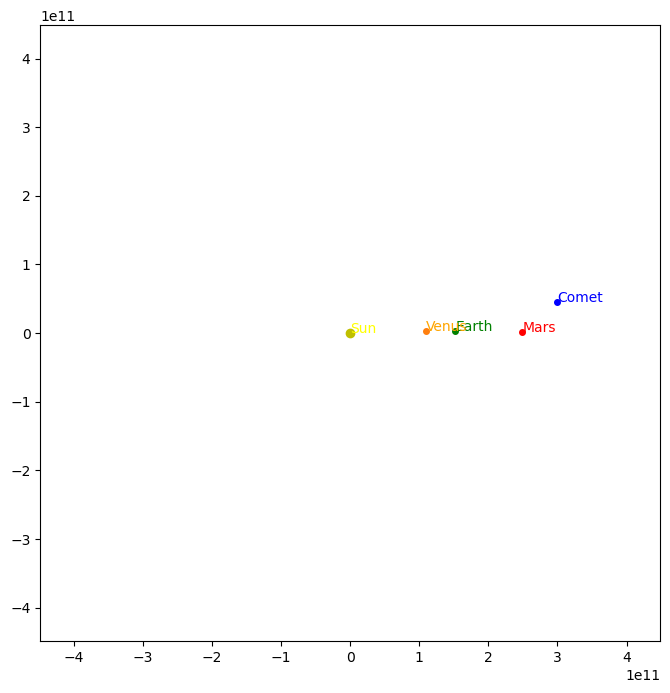

In [536]:
fig, ax = plt.subplots(figsize = (8,8))
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)

line_e, = ax.plot([], [], "-g", lw=1)
line_m, = ax.plot([], [], "-r", lw=1)
line_c, = ax.plot([], [], "-b", lw=1)
line_v, = ax.plot([], [], "-o", lw=1)

point_e, = ax.plot([], [], "go", markersize=4)
point_m, = ax.plot([], [], "ro", markersize=4)
point_c, = ax.plot([], [], "bo", markersize=4)
point_s, = ax.plot([], [], "yo", markersize=6)
point_v, = ax.plot([], [], "o", markersize=4)

text_e = ax.text(AU, 0, "Earth", color = "green")
text_m = ax.text(AU, 0, "Mars", color = "red")
text_c = ax.text(2*AU, 0, "Comet", color = "blue")
text_s = ax.text(0, 0, "Sun", color = "yellow")
text_v = ax.text(AU, 0, "Venus", color = "orange")

def update(i):

    line_e.set_data(xelist[:i], yelist[:i])
    line_m.set_data(xmlist[:i], ymlist[:i])
    line_c.set_data(xclist[:i], yclist[:i])
    line_v.set_data(xvlist[:i], yvlist[:i])

    point_e.set_data([xelist[i]], [yelist[i]])
    point_m.set_data([xmlist[i]], [ymlist[i]])
    point_c.set_data([xclist[i]], [yclist[i]])
    point_s.set_data([xslist[i]], [yslist[i]])
    point_v.set_data([xvlist[i]], [yvlist[i]])

    text_e.set_position((xelist[i], yelist[i]))
    text_m.set_position((xmlist[i], ymlist[i]))
    text_c.set_position((xclist[i], yclist[i]))
    text_s.set_position((xslist[i], yslist[i]))
    text_v.set_position((xvlist[i], yvlist[i]))

    return line_e, line_m, line_c, line_v, point_e, point_m, point_c, point_s, point_v, text_e, text_m, text_c, text_s, text_v

aniorbitwvenus = animation.FuncAnimation(fig, update, frames = len(xelist), interval = 1, blit = True)


Save you animation as a `.gif` or as a `.mp4`. Include this in your submission! This may take up to a couple mintutes!

In [538]:
aniorbitwvenus.save("orbitvenus.gif", writer = "pillow", fps = 20)

IndexError: list index out of range

Upload this notebook and your animations to Gradescope!

In [ ]:
len(yvlist)